# Customer Behaviour Analysis
**Main problem:** How can customer behaviour data be used to increase reorder revenue?

**Dataset:** [Instacart Online Grocery Shopping Dataset 2017](https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis)  
**Author:** Aurelia Saskia

| # | Section | Purpose | Status |
|---|---|---|---|
| 0 | Libraries | Import dependencies | Done |
| 1 | Data Loading | Build master dataframe | Done |
| 2 | EDA | Validate and explore data | Done |
| 3 | K-Means | Customer segmentation | Done |
| 4 | Logistic Regression | Reorder prediction | Future work |
| 5 | Naive Bayes | Product auto-classification | Future work |
| 6 | Apriori / FP-Growth | Product bundle discovery | Future work |

## 0. Libraries

In [35]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# Export
from sqlalchemy import create_engine
from getpass import getpass

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading & Preparation

The master dataframe is divided into two for different context:

| Dataframe | Source file | Used for |
|---|---|---|
| `df_train` | `order_products__train.csv` | Logistic Regression (the file contains clean reorder labels) |
| `df_prior` | `order_products__prior.csv` | K-Means, Naive Bayes, Association Rules (the file contains full purchase history) |

Each row  represent a single product within a single order, along with the user, department, and aisle context.

In [3]:
df_aisles = pd.read_csv('data/aisles.csv')
df_departments = pd.read_csv('data/departments.csv')
df_orders = pd.read_csv('data/orders.csv')
df_products = pd.read_csv('data/products.csv')
df_order_products_train = pd.read_csv('data/order_products__train.csv')
df_order_products_prior = pd.read_csv('data/order_products__prior.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
def build_master(order_products, label):
    df = (
        df_orders
        .merge(order_products, on="order_id", how="inner")
        .merge(df_products, on="product_id", how="left")
        .merge(df_departments, on="department_id", how="left")
        .merge(df_aisles, on="aisle_id", how="left")
    )
    print(f"{label}")
    print(f"Shape       : {df.shape}")
    print(f"Users       : {df['user_id'].nunique()}")
    print(f"Orders      : {df['order_id'].nunique()}")
    print(f"Products    : {df['product_id'].nunique()}")
    print(f"Departments : {df['department'].nunique()}\n")
    
    return df

df_train = build_master(df_order_products_train, "df_train")
df_prior = build_master(df_order_products_prior, "df_prior")

df_train
Shape       : (1384617, 15)
Users       : 131209
Orders      : 131209
Products    : 39123
Departments : 21

df_prior
Shape       : (32434489, 15)
Users       : 206209
Orders      : 3214874
Products    : 49677
Departments : 21



## 2. Exploratory Data Analysis (EDA)
**The Goals**:
1. Validate data quality (nulls, duplicates, impossible values).
2. Understand data distribution (when and what they buy).
3. Inform preprocessing decisions for each model

### 2.1 Data Inspection
Check data types, shape, and summary statistics for both dataframes.

In [5]:
def inspect_data(df, name):
    print(f"--- {name} ---")
    print(df.info())
    print()
    display(df.describe().round(2))
    
    return df

df_train = inspect_data(df_train, "df_train")
df_prior = inspect_data(df_prior, "df_prior")

--- df_train ---
<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 15 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1384617 non-null  int64  
 1   user_id                 1384617 non-null  int64  
 2   eval_set                1384617 non-null  str    
 3   order_number            1384617 non-null  int64  
 4   order_dow               1384617 non-null  int64  
 5   order_hour_of_day       1384617 non-null  int64  
 6   days_since_prior_order  1384617 non-null  float64
 7   product_id              1384617 non-null  int64  
 8   add_to_cart_order       1384617 non-null  int64  
 9   reordered               1384617 non-null  int64  
 10  product_name            1384617 non-null  str    
 11  aisle_id                1384617 non-null  int64  
 12  department_id           1384617 non-null  int64  
 13  department              1384617 non-null  str    
 

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id
count,1384617.00,1384617.00,1384617.00,1384617.00,1384617.00,1384617.00,1384617.00,1384617.00,1384617.00,1384617.0,1384617.00
mean,1706297.62,103112.78,17.09,2.70,13.58,17.07,25556.24,8.76,0.60,71.3,9.84
std,989732.65,59487.15,16.61,2.17,4.24,10.43,14121.27,7.42,0.49,38.1,6.29
min,1.00,1.00,4.00,0.00,0.00,0.00,1.00,1.00,0.00,1.0,1.00
25%,843370.00,51732.00,6.00,1.00,10.00,7.00,13380.00,3.00,0.00,31.0,4.00
50%,1701880.00,102933.00,11.00,3.00,14.00,15.00,25298.00,7.00,1.00,83.0,8.00
75%,2568023.00,154959.00,21.00,5.00,17.00,30.00,37940.00,12.00,1.00,107.0,16.00
max,3421070.00,206209.00,100.00,6.00,23.00,30.00,49688.00,80.00,1.00,134.0,21.00


--- df_prior ---
<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
 7   product_id              int64  
 8   add_to_cart_order       int64  
 9   reordered               int64  
 10  product_name            str    
 11  aisle_id                int64  
 12  department_id           int64  
 13  department              str    
 14  aisle                   str    
dtypes: float64(1), int64(10), str(4)
memory usage: 3.6 GB
None



,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id
count,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00,30356421.00,32434489.00,32434489.00,32434489.00,32434489.00,32434489.00
mean,1710748.52,102937.24,17.14,2.74,13.42,11.10,25576.34,8.35,0.59,71.21,9.92
std,987300.70,59466.48,17.54,2.09,4.25,8.78,14096.69,7.13,0.49,38.20,6.28
min,2.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00
25%,855943.00,51421.00,5.00,1.00,10.00,5.00,13530.00,3.00,0.00,31.00,4.00
50%,1711048.00,102611.00,11.00,3.00,13.00,8.00,25256.00,6.00,1.00,83.00,9.00
75%,2565514.00,154391.00,24.00,5.00,16.00,15.00,37935.00,11.00,1.00,107.00,16.00
max,3421083.00,206209.00,99.00,6.00,23.00,30.00,49688.00,145.00,1.00,134.00,21.00


**Data Inspection Summary**
- `df_train`: A smaller dataset(~1.4M rows). Each row is from the user's most recent order.
- `df_prior`: The full purchase history(~32M rows), used for all behavioral modeling.
- `add_to_cart_order`: ranges from 1 to 80+. Items added late are likely impulse purchases.
- `order_number`: max is 100 (capped by the dataset). Shows data limitation.
- `days_since_prior_order`: mean ≈ 11 days, median ≈ 7 days. Right-skewed -> most users shop weekly, a long tail shops monthly. NaN values only appeared on `df_prior` for a user's very first order.
- No unexpected dtypes. All IDs are integers, all names are objects.

### 2.2 Check Data Quality
Check for missing values, duplicates, and impossible values before analysis.

In [6]:
# Check Data Quality
def clean_data(df, name):
    print(f"Checking data quality for {name}...")

    # Check for missing values
    # NaN values in days_since_prior_order are only for a user's very first order.
    # Filled with median (neutral assumption) to avoid implying same-day reorder (fillna(0).)
    missing = df.isnull().sum()
    print(f"\nMissing values before cleaning:\n{missing}")
    median_value = df["days_since_prior_order"].median()
    df["days_since_prior_order"] = df["days_since_prior_order"].fillna(median_value)
    print(f"Filled missing {missing['days_since_prior_order']} values with median value: {median_value}")

    # Check for duplicates (order_id, product_id should be unique per row)
    dup = df.duplicated(subset=["order_id", "product_id"]).sum()
    dup_pct = dup / len(df) * 100
    print(f"\nDuplicate rows: {dup}")
    if dup > 0:
        df = df.drop_duplicates(subset=["order_id", "product_id"], keep="first")
        print(f"Duplicate rows removed: {dup}")
    if dup_pct > 1:
        print(f"Warning: {dup_pct:.2f}% of rows were duplicates. Recheck merge logic.")
 
    # Check for impossible values
    print(f"\nImpossible values:")
    print(f"add_to_cart_order < 1: {(df['add_to_cart_order'] < 1).sum()}")
    print(f"days_since_prior_order > 30: {(df['days_since_prior_order'] > 30).sum()}\n")

    return df

df_train = clean_data(df_train, "df_train")
df_prior = clean_data(df_prior, "df_prior")

Checking data quality for df_train...

Missing values before cleaning:
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
department                0
aisle                     0
dtype: int64
Filled missing 0 values with median value: 15.0

Duplicate rows: 0

Impossible values:
add_to_cart_order < 1: 0
days_since_prior_order > 30: 0

Checking data quality for df_prior...

Missing values before cleaning:
order_id                        0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_id                      0
add_to_ca

### 2.3 Data Exploration
Explore when customers shop, what they buy most, and which departments drive loyalty.

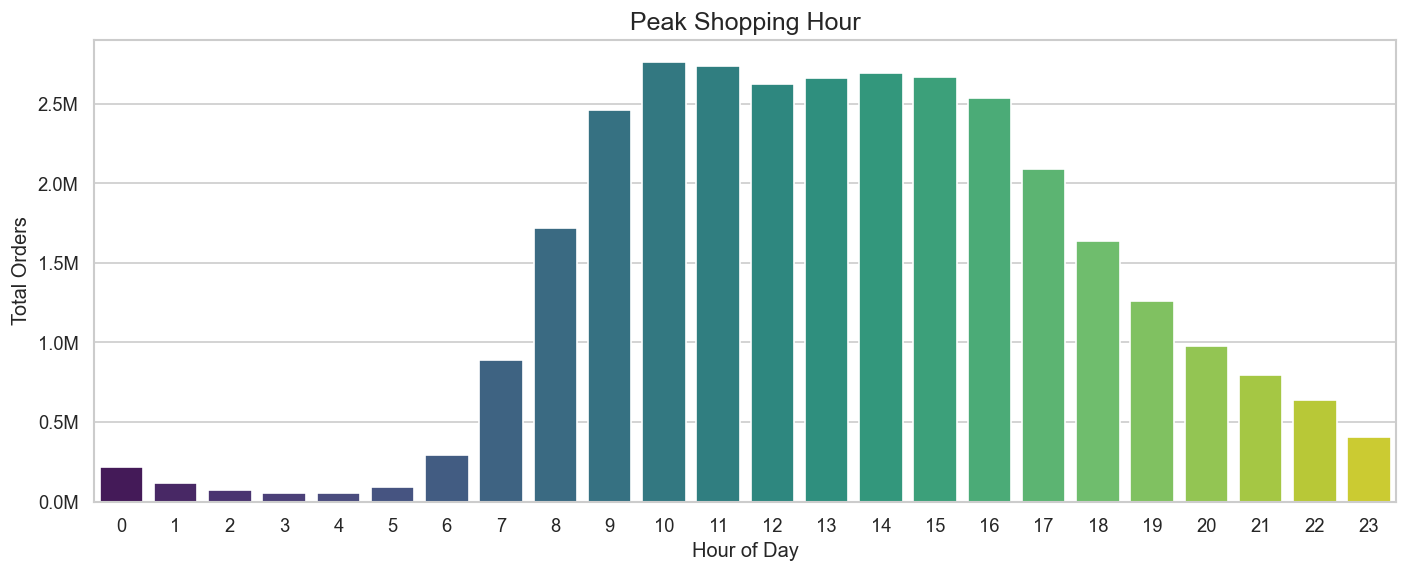

In [7]:
# Peak Shopping Hour
plt.figure(figsize=(14, 5))
ax = sns.countplot(x="order_hour_of_day", data=df_prior, palette="viridis")

# Change xlabel formatting for better readability
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

plt.title('Peak Shopping Hour', fontsize=15)
plt.xlabel('Hour of Day')
plt.ylabel('Total Orders')
plt.show()

The peak shopping hours are at **10:00 - 16:00**. This shows that customers are most active in daytime. To further push purchase, sending a promotional push notification around **9:00 AM** and optimizing delivery staffing between 10:00 - 16:00 allowed resources to keep up with actual demand.

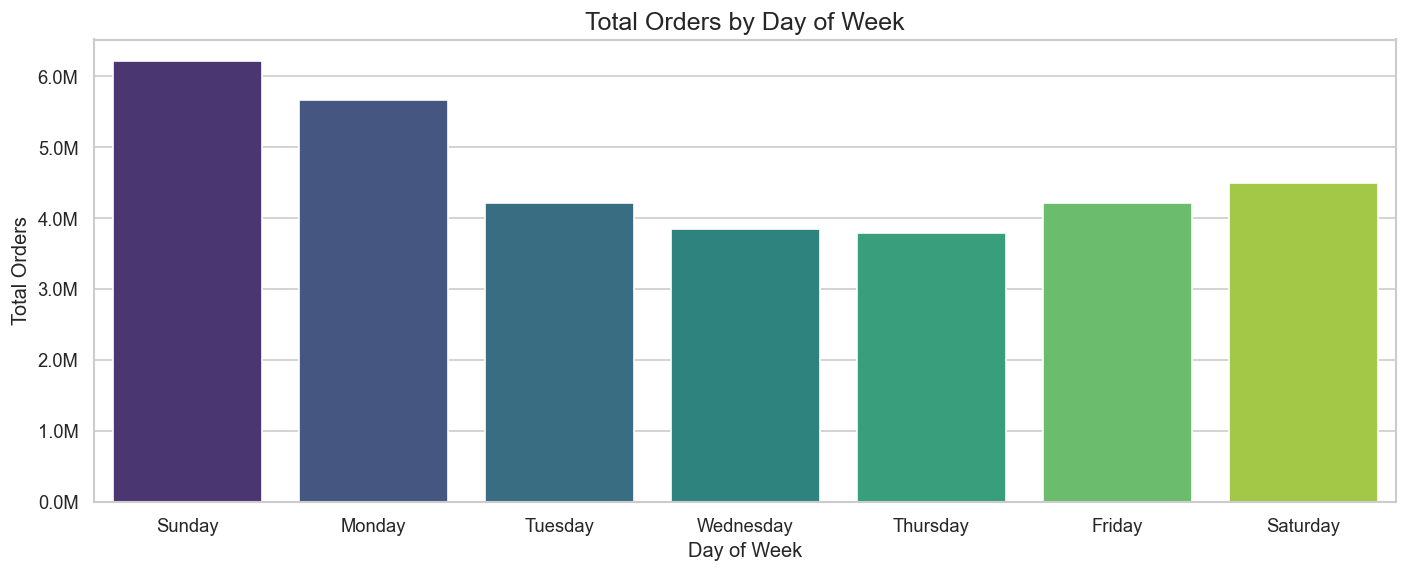

In [8]:
# Peak Shopping Day
day_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df_prior['day_name'] = df_prior['order_dow'].map(day_map)

plt.figure(figsize=(14, 5))
ax = sns.countplot(x="day_name", data=df_prior, order=day_order, palette="viridis")

# Change xlabel formatting
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))

plt.title("Total Orders by Day of Week", fontsize=15)
plt.xlabel("Day of Week")
plt.ylabel("Total Orders")
plt.show()

The day with highest volume is on **Sunday**, followed by **Monday**, indicating a weekly groceries pattern. Setting up a early-week promotions (Sunday night / Monday morning) are likely to have the highest reach.

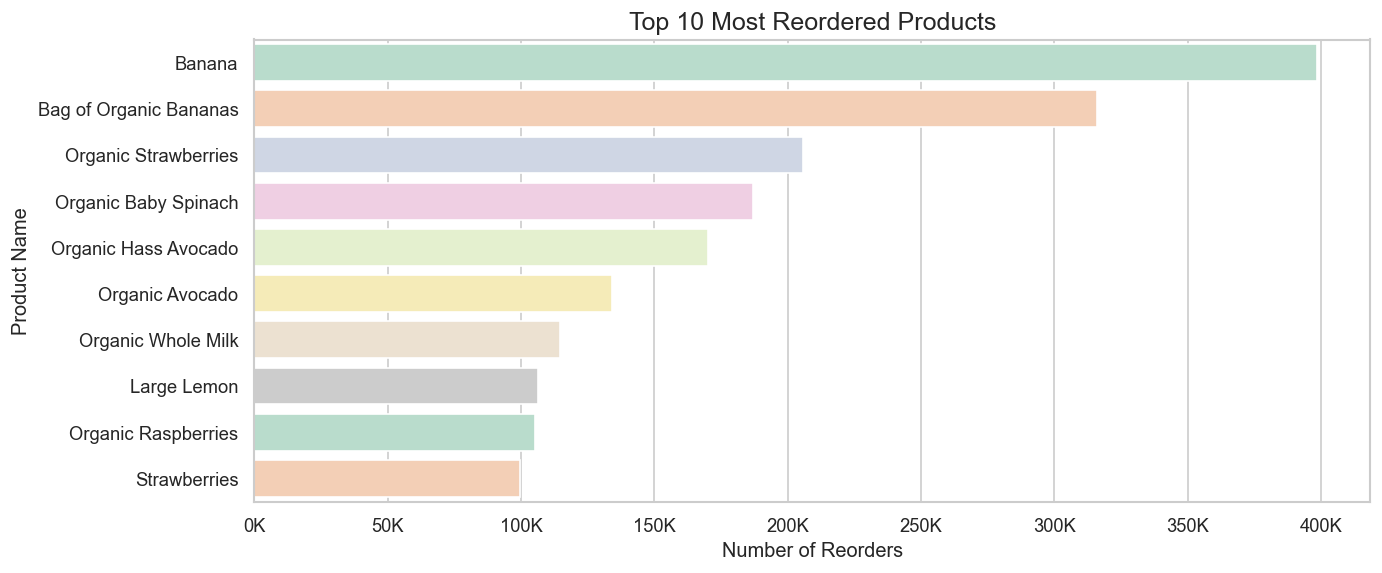

In [9]:
# Top Reordered Products (by volume)
top_reordered_products = (
    df_prior[df_prior["reordered"] == 1]["product_name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_reordered_products.values, y=top_reordered_products.index, palette="Pastel2")

# Change xlabel formatting
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

plt.title("Top 10 Most Reordered Products", fontsize=15)
plt.xlabel("Number of Reorders")
plt.ylabel("Product Name")
plt.show()

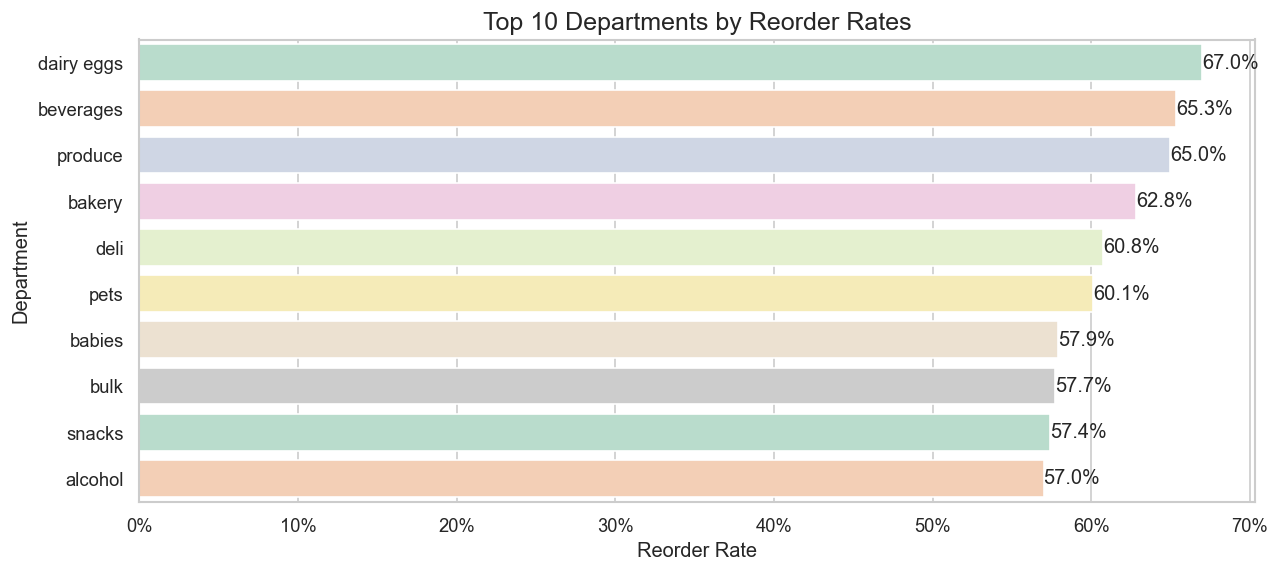

In [10]:
# Department Reorder Rate
dept_reorder_rate = (
    df_prior.groupby("department")["reordered"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=dept_reorder_rate.values, y=dept_reorder_rate.index, palette="Pastel2")

# Change xlabel formatting
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
)

# Add percentage labels to bars
for i, v in enumerate(dept_reorder_rate.values):
    plt.text(v, i, f"{v*100:.1f}%", va="center")

plt.title("Top 10 Departments by Reorder Rates", fontsize=15)
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()

> *Note: the products chart shows reorder volume. High-volume items (e.g. Bananas) rank highly partly because they are ordered more overall. The department chart corrects for this by showing reorder rate.*

Fresh produce dominates the reorder volume. **Dairy Eggs (67%)** and **Beverages (65.3%)** lead the reorder rate by department. These are the purchases where stock availability directly related to customer's loyalty. Ensuring consistent supply in peak hours (10:00-16:00) is recommended.

## 3. K-Means Clustering - Customer Segmentation
**Goal:** Group customers into segments/groups based on their behaviour to enable targeted marketing and campaigns.

**Segmentation Strategy (RFM-inspired):**
| Aspect | Feature | Description |
|---|---|---|
| Recency | `recency` taken from `days_since_prior_order (last)` | How recently they shopped |
| Frequency | `purchase_count` taken from `order_number (max)` | How many transaction has happened |
| Monetary | `total_items_purchased` taken from `product_id (count)` | Total volume of items bought |
| Loyalty | `reorder_ratio` taken from `reordered (mean)` | Tendency to reorder items |

K-means requires a user-level dataframe (one row per `user_id`) and scaled features since it uses Euclidean distance.

### 3.1 Feature Engineering

In [11]:
# Select related features for clustering
df_kmeans = df_prior.groupby("user_id").agg(
    recency = ("days_since_prior_order", "last"),
    purchase_count =("order_number", "max"),
    total_items_purchased = ("product_id", "count"),
    reorder_ratio = ("reordered", "mean")
).reset_index()

print("User-level table:")
print(f"Shape: {df_kmeans.shape}")
print(df_kmeans.head())

User-level table:
Shape: (206209, 5)
   user_id  recency  purchase_count  total_items_purchased  reorder_ratio
0        1     30.0              10                     59       0.694915
1        2     13.0              14                    195       0.476923
2        3     15.0              12                     88       0.625000
3        4      0.0               5                     18       0.055556
4        5     19.0               4                     37       0.378378


### 3.2 Preprocessing

**Skewness:** K-Means uses Euclidean distance. Right-skewed features may distort cluster shapes because the long tail pulls centroid away from where most users are.

- `|skew| < 1`: scale only
- `|skew| >= 1`: apply log transformation (`log1p`) first, then scale

Skewness values for clustering features:
  recency                     0.19  [ok]
  purchase_count              2.40  [skewed]
  total_items_purchased       3.18  [skewed]
  reorder_ratio               0.03  [ok]


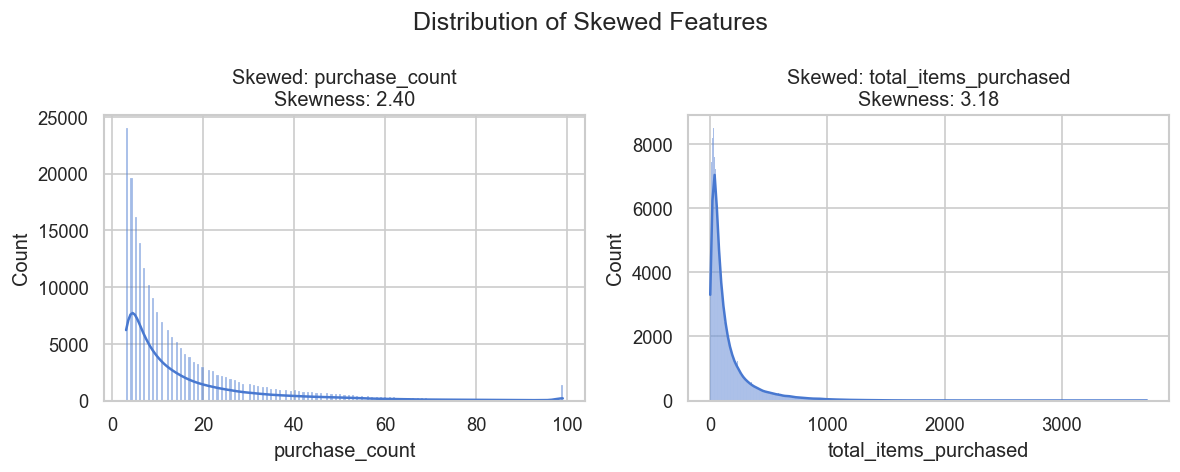

In [12]:
# Skewness check
kmeans_features = ["recency", "purchase_count", "total_items_purchased", "reorder_ratio"]

# Check for skewed features (|skew values| >= 1)
skew_values = df_kmeans[kmeans_features].skew()
skewed_cols = skew_values[skew_values.abs() >= 1].index.tolist()

print("Skewness values for clustering features:")
for col in kmeans_features:
    mark = "skewed" if col in skewed_cols else "ok"
    print(f"  {col:<25} {skew_values[col]:>6.2f}  [{mark}]")

plt.figure(figsize=(5*len(skewed_cols),4))
plt.suptitle("Distribution of Skewed Features", fontsize=15)
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(1, len(skewed_cols), i)
    sns.histplot(df_kmeans[col], kde=True)
    plt.title(f"Skewed: {col}\nSkewness: {skew_values[col]:.2f}")
plt.tight_layout()
plt.show()


In [13]:
# Apply log transformation to skewed features
df_kmeans_processed = df_kmeans.copy()
for col in skewed_cols:
    df_kmeans_processed[col] = np.log1p(df_kmeans_processed[col])
print("Skewness values after log transformation:")
print(df_kmeans_processed[kmeans_features].skew().round(2))

# Scale all features
scaler_kmeans = StandardScaler()
scaled_kmeans = scaler_kmeans.fit_transform(df_kmeans_processed[kmeans_features])
print(f"\nPreprocessing is complete.")

Skewness values after log transformation:
recency                  0.19
purchase_count           0.56
total_items_purchased    0.05
reorder_ratio            0.03
dtype: float64

Preprocessing is complete.


### 3.3 Hyperparameter Tuning

**Elbow Method:** Find where inertia stops dropping significantly.

**Silhouette Score:** Measure how well each point fits its cluster compared to the neighbouring clusters (range -1 to 1).

Due to the tuning being too time-consuming, it is only done once then the results are saved to a JSON file. Comment out the first cell below after the initial run.

In [20]:
# Run once, then comment out this entire cell to save up time.
# The JSON file is gitignored, please regenerate it locally before running cell 29
# inertia = []
# silhouette_scores = []
# k_range = range(2, 11)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
#     cluster_labels = kmeans.fit_predict(scaled_kmeans)
#     inertia.append(kmeans.inertia_)
#     silhouette_scores.append(silhouette_score(scaled_kmeans, cluster_labels))
#     print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.4f}")

# tuning_output = {
#     "k_range": list(k_range),
#     "inertia": inertia,
#     "silhouette_avg": silhouette_scores
# }
# with open('kmeans_tuning_results.json', 'w') as f:
#     json.dump(tuning_output, f)
# print("Saved to 'kmeans_tuning_results.json'!")


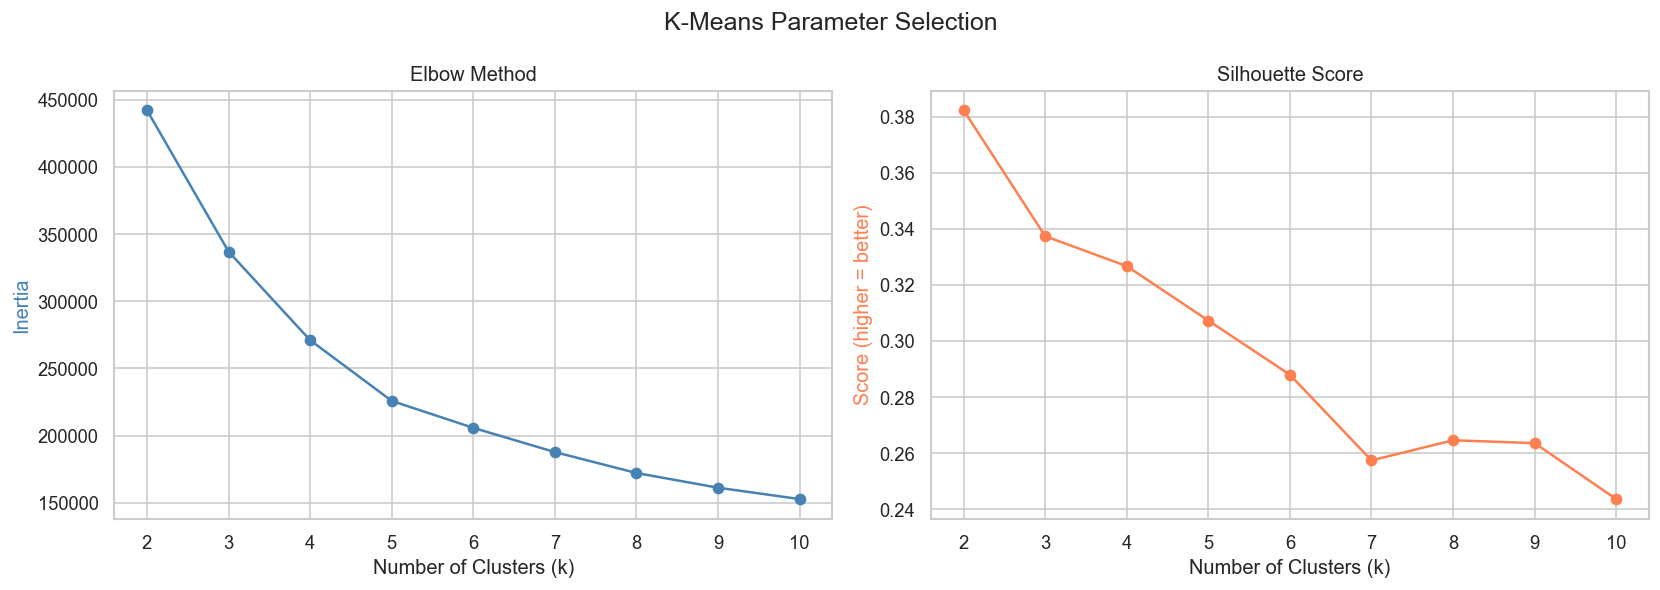

Optimal k = 2
Best silhouette = 0.382


In [21]:
# Load saved result and plot
with open("kmeans_tuning_results.json", "r") as f:
    kmeans_results = json.load(f)

k_range = kmeans_results["k_range"]
inertia = kmeans_results["inertia"]
silhouette_scores = kmeans_results["silhouette_avg"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("K-Means Parameter Selection", fontsize=15)

ax[0].plot(k_range, inertia, marker="o", color="steelblue")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia", color="steelblue")

ax[1].plot(k_range, silhouette_scores, marker="o", color="coral")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Score (higher = better)", color="coral")

plt.tight_layout()
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal k = {best_k}")
print(f"Best silhouette = {max(silhouette_scores):.3f}")

**Deciding Optimal K**
- Silhouette score suggest `k=2` as the optimal number of separation.
- Elbow method shows a significant "bend" at `k=3`, indicating a significant inertia reduction when compared to `k=2`.
- **Decision:** `k=3` is selected. While `k=2` is considered more optimal, `k=3` deemed to provide more actionable business segments. A silhouette score of $\approx$ 0.34 is still considered acceptable for complex, real-world datasets.

### 3.4 Final Model & Cluster Profile

In [22]:
# Train final model with k=3
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_kmeans['cluster'] = kmeans_final.fit_predict(scaled_kmeans)

# Show cluster profile (original values)
cluster_profile = df_kmeans.groupby("cluster")[kmeans_features].mean().round(2)
cluster_profile["customer_count"] = df_kmeans.groupby("cluster").size()
display(cluster_profile)

,recency,purchase_count,total_items_purchased,reorder_ratio,customer_count
cluster,,,,,
0,28.07,6.96,62.36,0.32,71128
1,10.59,31.34,332.82,0.63,72570
2,8.81,7.13,61.53,0.32,62511


### 3.5 Segment Labeling
Based on the feature values above, the labels are assigned manually.

**Reference guide:**
| Cluster | Pattern | Suggested Label |
|---|---|---|
| 0 |High recency + low purchase count (frequency) + low items + low reorder | Potential Churn |
| 1 | Low recency + high purchase count (frequency) + high items + high reorder | The Loyalist |
| 2 | Low recency + low purchase count (frequency) + low items + low reorder | The Newcomer |

In [26]:
label_map = {
    0: "Potential Churn",
    1: "The Loyalist",
    2: "The Newcomer",
}

df_kmeans["segment"] = df_kmeans["cluster"].map(label_map)
print("Segment distribution:")
print(df_kmeans["segment"].value_counts())

cluster_profile = df_kmeans.groupby("segment")[kmeans_features].mean()

Segment distribution:
segment
The Loyalist       72570
Potential Churn    71128
The Newcomer       62511
Name: count, dtype: int64


### 3.6 Visualization

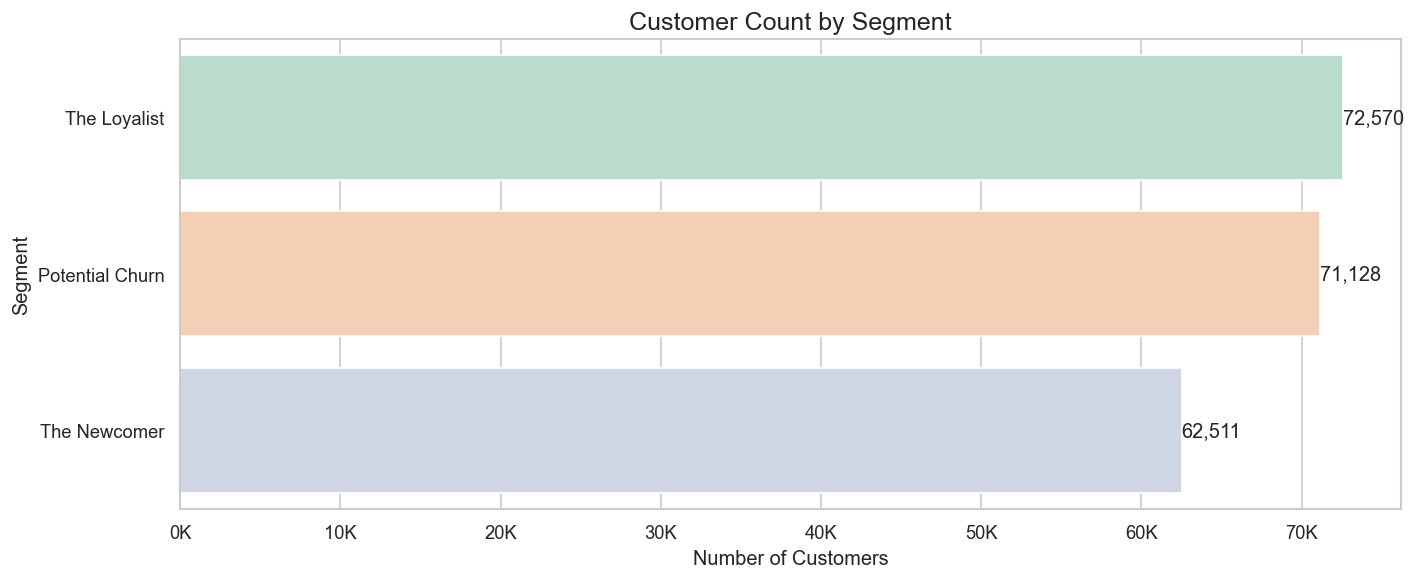

In [27]:
# Customer Count
segment_count = df_kmeans["segment"].value_counts()

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=segment_count.values, y=segment_count.index, palette="Pastel2")

# Change xlabel formatting
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

# Add number labels to bars
for i, v in enumerate(segment_count.values):
    plt.text(v, i, f"{v:,}", va="center")

plt.title("Customer Count by Segment", fontsize=15)
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

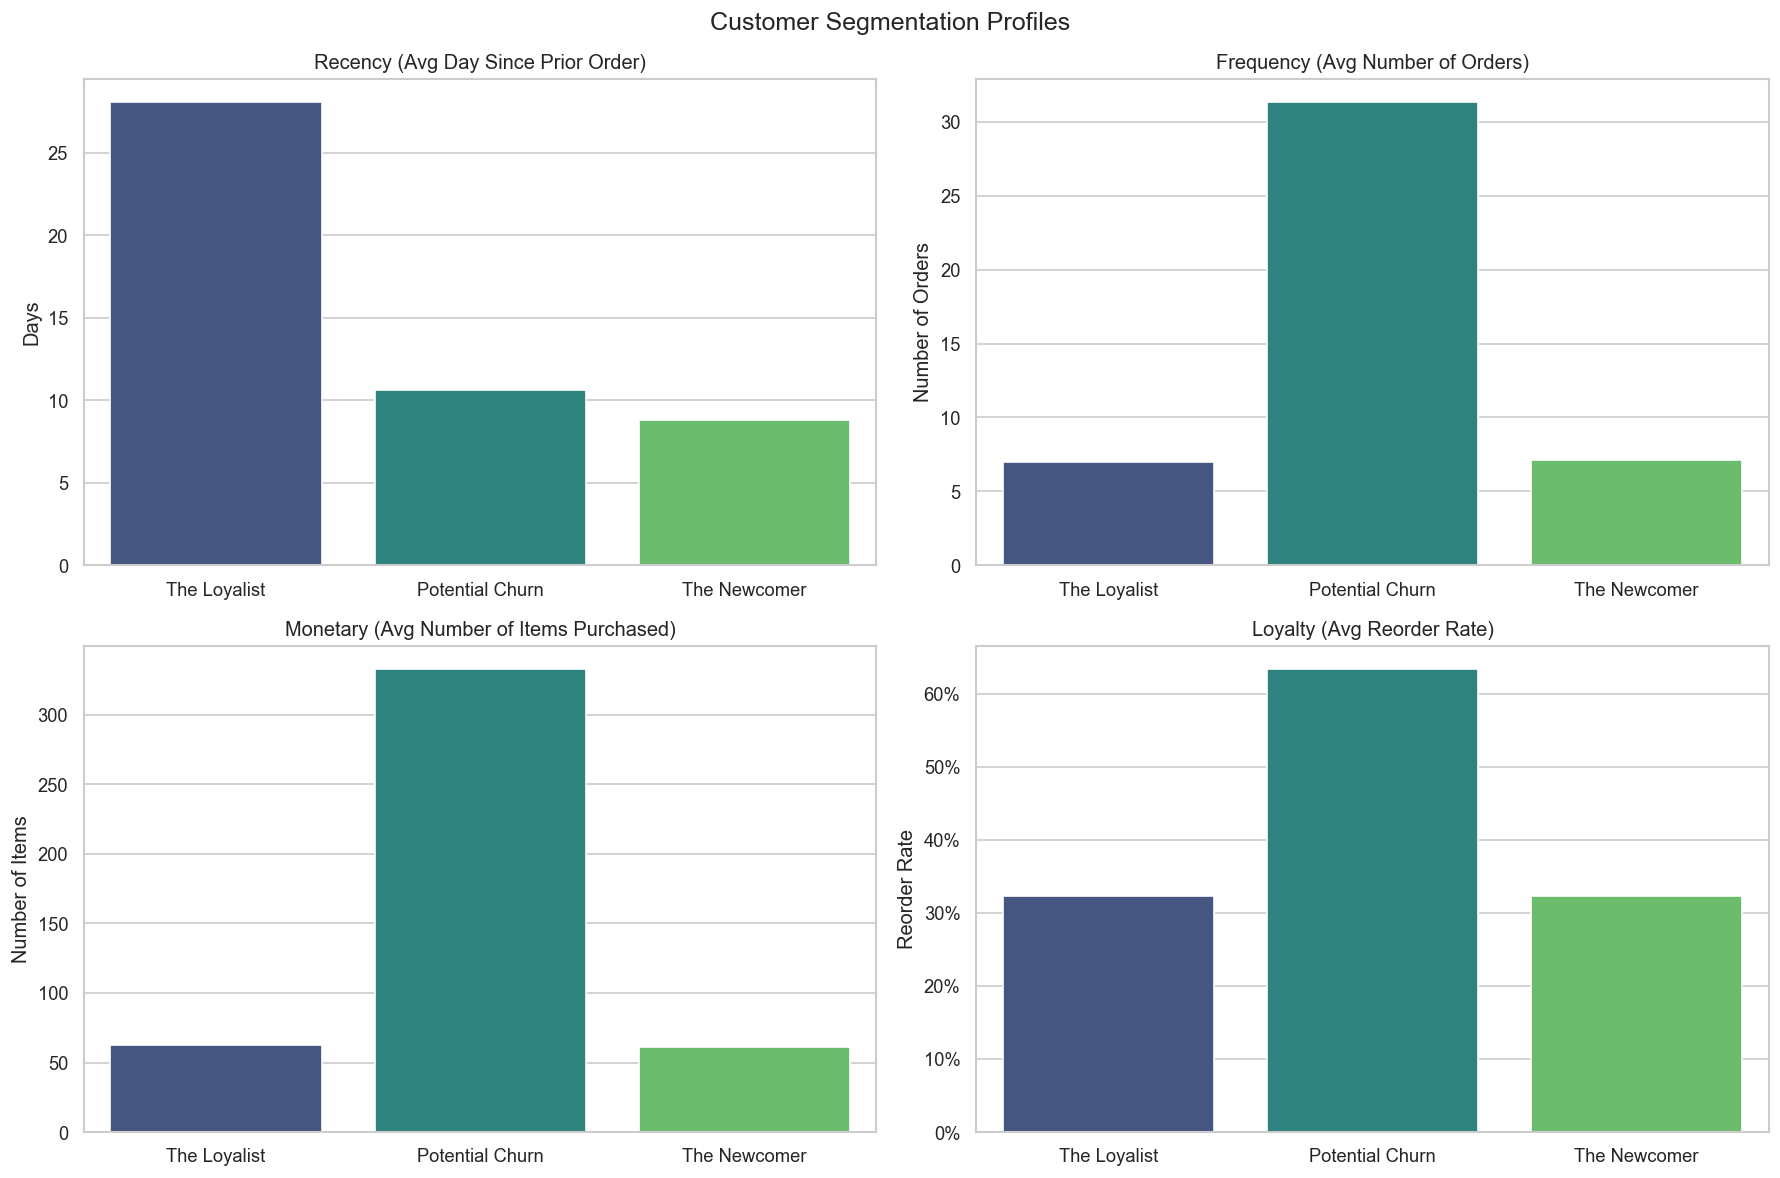

In [28]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
plt.suptitle("Customer Segmentation Profiles", fontsize=15)
ax = ax.flatten()

# for recency
sns.barplot(x=segment_count.index, y=cluster_profile["recency"], ax=ax[0], palette="viridis")
ax[0].set_title("Recency (Avg Day Since Prior Order)")
ax[0].set_xlabel("")
ax[0].set_ylabel("Days")


# for frequency (purchase count)
sns.barplot(x=segment_count.index, y=cluster_profile["purchase_count"], ax=ax[1], palette="viridis")
ax[1].set_title("Frequency (Avg Number of Orders)")
ax[1].set_xlabel("")
ax[1].set_ylabel("Number of Orders")

# for monetary (total items purchased)
sns.barplot(x=segment_count.index, y=cluster_profile["total_items_purchased"], ax=ax[2], palette="viridis")
ax[2].set_title("Monetary (Avg Number of Items Purchased)")
ax[2].set_xlabel("")
ax[2].set_ylabel("Number of Items")

# for Loyalty (reorder ratio)
sns.barplot(x=segment_count.index, y=cluster_profile["reorder_ratio"], ax=ax[3], palette="viridis")
ax[3].set_title("Loyalty (Avg Reorder Rate)")
ax[3].set_xlabel("")
ax[3].set_ylabel("Reorder Rate")
ax[3].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))

plt.tight_layout()
plt.show()

The visualization above confirm the pattern written in the reference guide above, which are:
- **Potential Churn:** Has the highest number of recency gap, which shows sign of inactivity.
- **The Loyalist:** Has the highest number in Frequency, Monetary, and Loyalty. This shows that these groups played a big part in the income revenue.
- **The Newcomer:** Has the lowest number of recency value (recent shopper), which shows high recent engagement despite the lower overall feature.

### 3.7 Business Insights
| Segment | Profile | Recommended Action |
|---|---|---|
| Potential Churn | Customers with high risk of leaving, have a very high recency (almost 30 days of inactivity) and low overall engagement | Give "returning" promotion to encourage re-activation, Create personalized offer based on their purchase history |
| The Loyalist | High-value customers with high overall engagement (highest frequency, highest purchase, strong reorder tendencies) | Implement "VIP Program" that offer benefits such as early-access to products and member-only promotions |
| The Newcomer | Active customers with lowest recency (frequent visit), although still have low total transaction | Offer tiered reward and promotions to increase purchase and create shopping habits |

In [33]:
# Export cluster profile
os.makedirs("outputs", exist_ok=True)
cluster_profile["segment"] = cluster_profile.index.map(label_map)
cluster_profile.to_csv("outputs/cluster_profile.csv")
print("Result exported to outputs/cluster_profile.csv")

Result exported to outputs/cluster_profile.csv


### 3.8 Export Result to Postgres

In [36]:
PG_USER = "postgres"
PG_PASSWORD = getpass("Enter your Postgres password: ")
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB = "instacart"

engine = create_engine(f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}")

segments_export = df_kmeans[["user_id", "recency", "purchase_count", "total_items_purchased", "reorder_ratio", "cluster", "segment"]]
segments_export.to_sql("customer_segments", engine, if_exists="replace", index=False)
print(f"Exported {len(segments_export)} rows to customer_segments table.")

Exported 206209 rows to customer_segments table.


In [37]:
display(df_kmeans)

,user_id,recency,purchase_count,total_items_purchased,reorder_ratio,cluster,segment
0,1,30.0,10,59,0.694915,0,Potential Churn
1,2,13.0,14,195,0.476923,1,The Loyalist
2,3,15.0,12,88,0.625000,1,The Loyalist
3,4,0.0,5,18,0.055556,2,The Newcomer
4,5,19.0,4,37,0.378378,0,Potential Churn
...,...,...,...,...,...,...,...
206204,206205,10.0,3,32,0.250000,2,The Newcomer
206205,206206,11.0,67,285,0.473684,1,The Loyalist
206206,206207,18.0,16,223,0.587444,1,The Loyalist
206207,206208,7.0,49,677,0.707533,1,The Loyalist
